<a href="https://colab.research.google.com/github/jollyoli93/KnowYourLoadExactly/blob/main/Crane_Detector_YOLOv8_Full_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Starter Code

In [2]:
!python --version

Python 3.12.12


In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="MYzeeHsKmZnJ360DkKYF")
project = rf.workspace("masterproject-mvazq").project("test_only")
version = project.version(1)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 94.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to TEST_ONLY-1 in yolov8:: 100%|██████████| 102/102 [00:00<00:00, 129.82it/s]


In [4]:
# from google.colab import drive
# drive.mount('/content/drive')

In [5]:
!pip install ultralytics==8.3.190

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 8.4 MB/s eta 0:00:00


In [6]:
# !pip install --upgrade onnx onnxscript

In [7]:
# !pip install wandb

In [8]:
# from wandb.integration.ultralytics import add_wandb_callback
from ultralytics import YOLO
# import cv2
import numpy as np
import torch

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [9]:
from sklearn.preprocessing import StandardScaler
import numpy as np
from pathlib import Path

from math import sqrt

#Gets statistics from training data for MLP ROI Predictor
def get_pairs(coords, from_file=True):

  coord_split = []

  if from_file:
    coord_split = [
        [float(x) for x in line.strip().split()]
        for line in coords
        if line.strip()
    ]
  else:
    coord_split = coords

  hooks = [d for d in coord_split if d[0] == 0]  # hook
  loads = [d for d in coord_split if d[0] == 1]  # load

  pairs = {'hook': [], 'load': []}
  used_hooks = set()

  for load in loads:
      xc_load, yc_load = load[1], load[2]
      h_load = load[-1]
      closest = None
      closest_idx = -1
      min_dist = float("inf")

      for i, hook in enumerate(hooks):
          if i in used_hooks:
              continue

          xc_hook, yc_hook = hook[1], hook[2]

          yt_load = yc_load - (h_load /2)
          yb_hook = yc_hook + hook[-1]/2 #Location at bottom of hook

          # Hook must be above load
          if yb_hook > yt_load:
              continue

          # Horizontal closeness
          dist = abs(xc_load - xc_hook)
          if dist < min_dist:
              min_dist = dist
              closest = hook
              closest_idx = i

      if closest is not None:
          xc, yc, w, h = closest[1:5]
          # aspect = w / h if h != 0 else 0.0
          # area = w*h
          yb = yc + (h / 2)
          #dist = sqrt((xc - xc_load)**2 + (yc - yc_load)**2). feading load dims to features might create shortcut/memorisations

          # # get relative offsets normalised
          dx = (xc_load - xc) /w
          dy = (yc_load - yb) /h

          pairs['hook'].append(
              [xc, yc, w, h] + [yb]
          )
          pairs['load'].append([dx, dy])

          used_hooks.add(closest_idx)

  return pairs

In [10]:
train_labels = "/content/drive/MyDrive/Crane-Detector/YOLOv8 Normal/K_Fold/train/2026-01-26_5-Fold_Cross-val/split_4/train/labels"

# 1. Collect all data for fitting
train_feats = []
train_targets = []

for label_file in Path(train_labels).glob("*.txt"):
    with open(label_file) as f:
        pairs = get_pairs(f.readlines())
        if pairs:
            train_feats.extend(pairs['hook'])
            train_targets.extend(pairs['load'])

# 2. Fit the scalers
feat_scaler = StandardScaler().fit(train_feats)
target_scaler = StandardScaler().fit(train_targets)

#One Cycle

In [11]:
%cd /content/drive/MyDrive/Crane-Detector

/content/drive/MyDrive/Crane-Detector


## Load YOLO Model

In [12]:
best_weights = "/content/drive/MyDrive/Crane-Detector/runs/detect/best_260126_train7/weights/best.pt"

In [13]:
yolo_model = YOLO(best_weights)

In [14]:
test_path = "/content/drive/MyDrive/Crane-Detector/First Experiment/ALL_2CLS_NOAUG/test/images"

In [15]:
# from pathlib import Path

# results = []

# for img in Path(test_path).glob("*jpg"):
#   results.append(model.predict(img, stream=False))

## Run Image

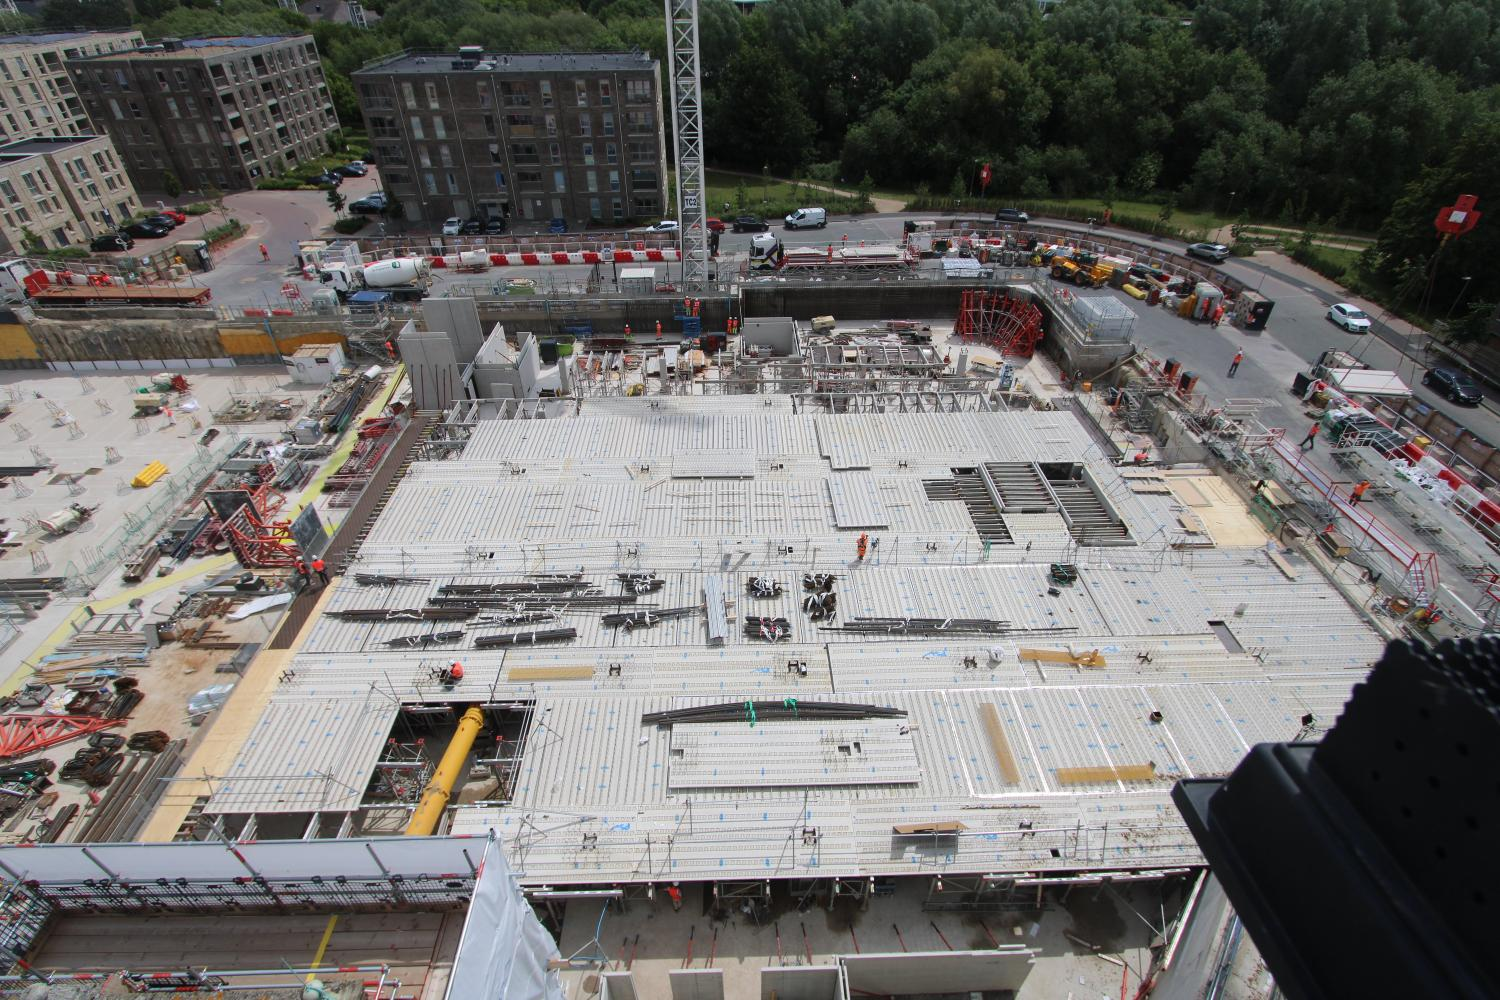

In [92]:
from google.colab.patches import cv2_imshow
import cv2

# img = cv2.imread("/content/drive/MyDrive/Crane-Detector/TEST_ONLY-1/test/images/2503061230060000_jpg.rf.96a86533e4d968fcc59cc8d2f078560d.jpg") # 4000w, 6000h SLOW!

# img = cv2.imread('/content/drive/MyDrive/Crane-Detector/First Experiment/All_2LCS_AUG/valid/images/2502240810060000_jpg.rf.56156243b1ad02bee4d57d2e65850cca.jpg') #1 hook, 1 load
# img = cv2.imread('/content/drive/MyDrive/Crane-Detector/First Experiment/All_2LCS_AUG/test/images/2505301040060000_jpg.rf.e1ed3ff61e40b48bd7aecdf5f7df6050.jpg') #1 hook, 1 load
img = cv2.imread('/content/drive/MyDrive/Crane-Detector/First Experiment/All_2LCS_AUG/test/images/2505301210060000_jpg.rf.4e2d4447ae977df17c79484f248ebb27.jpg') # 2 hook
# img = cv2.imread('/content/drive/MyDrive/Crane-Detector/First Experiment/All_2LCS_AUG/test/images/2505081520060000_jpg.rf.0d654dfb0aa7f32b6b1385e4ae5c7e5f.jpg')  #1 hook, 1 load (multiple loads matching)
# img = cv2.imread('/content/drive/MyDrive/Crane-Detector/First Experiment/All_2LCS_AUG/test/images/2505081740060000_jpg.rf.f446e77de4d540793a42f8ff9e3e8cda.jpg')  #1 hook, 1 load real
# img = cv2.imread('/content/drive/MyDrive/Crane-Detector/First Experiment/All_2LCS_AUG/test/images/2507190940060000_jpg.rf.25413f580b6dab2700fab296e0eca813.jpg') #1 hook, 1 load


cv2_imshow(img)

In [93]:
img.shape

(1000, 1500, 3)

## Load Regression Model

In [94]:
import torch

class LinearRegression(torch.nn.Module):
    def __init__(self, in_feat, out_feat, hidden) -> None:
        super().__init__()
        self.linear = torch.nn.Sequential(
            torch.nn.Linear(in_feat, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, out_feat)
        )

    def forward(self, x):
        x = self.linear(x)
        return x

In [95]:
PATH = "/content/drive/MyDrive/Crane-Detector/LoadRegressionModel/LoadRegressionStandardv2.pth"
cropPredict = LinearRegression(5, 2, 64)
cropPredict.load_state_dict(torch.load(PATH, weights_only=True, map_location=torch.device('cpu')))
cropPredict.eval()

LinearRegression(
  (linear): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)

In [96]:
import numpy as np
import torch

def predict_load_roi(img_size, hook_coords):
    """
    hook_coords: normalized YOLO (x_center, y_center, w, h) in [0,1]
    img_size: (img_height, img_width) or (H, W, C) - we use first two.
    dims: optional crop size control
    """

    # image dims
    img_height = int(img_size[0])
    img_width  = int(img_size[1])

    hook_coords_np = np.asarray(hook_coords, dtype=np.float32).reshape(-1)

    x, y, w, h = hook_coords_np  # normalized
    yb_hook = y + (h / 2.0)

    # features for scaler: [x, y, w, h, yb_hook]
    hook_features = np.array([[x, y, w, h, yb_hook]], dtype=np.float32)
    xs_scaled = feat_scaler.transform(hook_features)  # numpy (1, 5)

    # Get predictions
    xs_t = torch.from_numpy(xs_scaled).float() #.to(device)
    cropPredict.eval()
    with torch.no_grad():
        pred_scaled = cropPredict(xs_t).cpu().numpy()

      # pred_inv is [dx, dy]
    pred_inv = target_scaler.inverse_transform(pred_scaled.reshape(1, -1))
    print(pred_inv)
    # dx, dy = pred_inv[0]
    dx, dy = float(pred_inv[0, 0]), float(pred_inv[0, 1])

    # ---- apply offsets relative to hook size (still normalized [0-1]) ----
    x_pred = x + (dx * w)
    y_pred = yb_hook + (dy * h)

    xc = int(round(x_pred * img_width ))
    yc = int(round(y_pred * img_height))

    #crop to top of hook
    gap_pixels = yc - (yb_hook * img_height)

    crop_h = int(gap_pixels * 1.6)
    crop_w = int(crop_h * 1.2)      # Usually loads are wider than they are tall

    xt = int(xc - (crop_w // 2))
    yt = int(yc - (crop_h // 2))

    # Clamp to image bounds
    xt = max(0, min(xt, img_width - crop_w))
    yt = max(0, min(yt, img_height - crop_h))

    return xt, yt, crop_w, crop_h


In [97]:
def crop_load(img, x, y, w, h):
  """
    Takes as input, top left corner, width and height.
  """
  crop_img = img.copy()
  cropped_img = crop_img[y:y+h,x:x+w]

  return cropped_img


In [98]:
def corner_to_center(xt, yt, w,h):
  xc = xt+(w/2)
  yc = yt+(h/2)
  return xc, yc, w, h

In [99]:
def center_to_corner(xc, yc, w,h):
  xt = xc-(w/2)
  yt = yc-(h/2)
  return xt, yt, w, h

## Load Classifier Model

In [100]:
# %cd /content/drive/MyDrive/Crane-Detector/Image_Classes/

In [101]:
import torch
import albumentations as A
import numpy as np

checkpoint = torch.load('/content/drive/MyDrive/Crane-Detector/Image_Classes/crane_classifier.pth', map_location='cpu', weights_only=False)

class_model = checkpoint['model']
class_model.eval()

if torch.cuda.is_available():
    class_model = class_model.cuda()

cls_names = checkpoint['cls_names']
cls_index = checkpoint['cls_index']

print("Model loaded successfully!")

Model loaded successfully!


In [102]:
val_transforms = A.Compose([
    A.Resize(height=240, width=240, p=1.0),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0),
])

In [103]:
def predict_one_image(model, image_array, transforms=val_transforms):
    """
    Predict class for a single image from test set
    """
    model.eval()

    # Apply transforms
    transformed = transforms(image=image_array)['image']
    x = np.transpose(transformed, (2, 0, 1))
    x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)  # Add batch dimension

    # Move to GPU if available
    if torch.cuda.is_available():
        x = x.cuda()

    with torch.no_grad():
        output = model(x)
        probs = torch.softmax(output, dim=1)
        pred_idx = probs.argmax(dim=1).item()
        confidence = probs[0, pred_idx].item()

    pred_class = cls_names[pred_idx]

    return pred_class, confidence


In [104]:
# # Test prediction
# predicted_class, confidence = predict_one_image(class_model, img)

# print(f"Predicted Class: {predicted_class}")
# print(f"Confidence: {confidence:.4f} ({confidence*100:.2f}%)")

## One Cycle - Crane Load Predictor

In [105]:
def second_stage_detector(crop, img_size):
  print("Predicting Second Crop")
  results = yolo_model.predict(crop, imgsz=img_size, stream=False)

  for result in results:
    if not result.boxes:
      continue

    for box in result.boxes.cpu():
        class_id = int(box.cls[0])
        class_name = yolo_model.names[class_id]  # Get class name using the class ID
        conf = float(box.conf[0])
        print(f"Class: {class_name}")  # Print class name and box coordinates
        label = f"{class_name}: {conf:.2f}"

        if class_id == 1: #Load Class
        #  LOCAL coordinates (relative to the ROI)
          lx1, ly1, lx2, ly2 = box.xyxy[0].cpu().numpy().astype(int)
          print(lx1, ly1, lx2, ly2)

          w, h = lx2 - lx1, ly2 - ly1
          print("w,h: ", w, " " , h)
          # actual cropped image of the load
          load_only_crop = crop[ly1:ly2, lx1:lx2]
          return load_only_crop, lx1, ly1, lx2, ly2, conf
  return None, 0,0,0,0, 0

In [106]:
def predict_from_hook(image, box_size, dims,class_model):
    pts = predict_load_roi(box_size, dims)
    xt, yt, crop_w, crop_h = pts
    print(xt, yt)

    # extract the ROI from the main image
    ROI = image[yt:yt+crop_h, xt:xt+crop_w]
    if ROI.size == 0: return

    cv2.rectangle(img, (xt, yt), (xt + crop_w, yt + crop_h), (0, 255, 0), 2)
    cv2.putText(img, f"ROI", (xt, yt - 10),
      cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2, cv2.LINE_AA)

    # Find the load inside that ROI
    load_crop, lx1, ly1, lx2, ly2, yolo_conf = second_stage_detector(ROI, max(crop_w, crop_h))

    if load_crop is not None:
        # GLOBAL COORDINATES: ROI start + Local YOLO start
        gx1, gy1 = xt + lx1, yt + ly1
        gx2, gy2 = xt + lx2, yt + ly2
        w = gx2 - gx1
        h = gy1 - gy2

        # Draw the final accurate box
        predicted_class, confidence = predict_one_image(class_model, load_crop)
        cv2.rectangle(img, (gx1, gy1), (gx2, gy2), (0, 255, 0), 3)
        cv2.putText(img, f"Predicted 2 stage Crop: {predicted_class}, Conf: {confidence:.2f}", (gx1, gy1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        return gx1, gy1, h ,w, confidence
    else:
        print("MLP proposed a region, but YOLO stage 2 found no load there.")
        print("Predicting from ROI")
        print()

        predicted_class, confidence = predict_one_image(class_model, ROI)
        print(f"Predicted ROI Class: {predicted_class}")
        print(f"Confidence of ROI: {confidence:.4f} ({confidence*100:.2f}%)")

        cv2.rectangle(img, r[:2], r[2:], (0, 255, 0), 2)
        cv2.putText(img, f"{predicted_class}: {confidence:.2f}", (xt, yt - 10),
          cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2, cv2.LINE_AA)
        # returns corner point and crop w, h
        return xt, yt, crop_w, crop_h, confidence

In [114]:
def box_gating(boxes):
  """
    Boxes contain a list of [class_idx, xc, yc, w, h, conf, src, hook_id] in pixel space.
    class 0 = hook, class 1 = load
    src in {"hook","obj","roi"}
    hook_id is an int for hook/roi loads, None for obj loads
    Returns loads only
  """
  if not boxes:
    print("Empty boxes")
    return []

  hooks = [d for d in boxes if d[6] == "hook"]
  obj_loads = [d for d in boxes if d[6] == "obj"]
  roi_loads  = [d for d in boxes if d[6] == "roi"]

  used_obj = set()
  matched_obj = set()
  kept_loads = []

  # For each hook find its highest matching load
  for hook in hooks:
    hook_x, hook_y, hook_w = hook[1], hook[2], hook[3]
    hook_id = hook[7]
    hook_boundary = hook_w * 3.0

    best_obj_idx = None
    best_obj_conf = float("-inf")

    for i, load in enumerate(obj_loads):
      load_x, load_y = load[1], load[2]

      # Gating - if it doesnt match then assume its on another hook
      if load_y < hook_y:
        continue
      if load_x < (hook_x - hook_boundary) or load_x > (hook_x + hook_boundary):
        continue

      matched_obj.add(i)

      if i in used_obj:
        continue

      conf = load[5]
      if conf > best_obj_conf:
        best_obj_conf = conf
        best_obj_idx = i

    if best_obj_idx is not None:
      kept_loads.append(obj_loads[best_obj_idx])
      used_obj.add(best_obj_idx)
    else:
      roi_candidate = [d for d in roi_loads if d[7] == hook_id]
      if roi_candidate:
        kept_loads.append(roi_candidate[0])

  for i, load in enumerate(obj_loads):
    if i not in matched_obj:
      kept_loads.append(load)

  print(kept_loads)
  return kept_loads

In [108]:
# Run prediction on the image
results = yolo_model.predict(img, imgsz=1504, stream=False)


0: 1024x1504 2 crane_hooks, 1114.5ms
Speed: 26.5ms preprocess, 1114.5ms inference, 1.8ms postprocess per image at shape (1, 3, 1024, 1504)


In [115]:
# Iterate over the results

for result in results:
    boxes = result.boxes.cpu()  # Get boxes on CPU in numpy format

    box_preds = []

    for idx, box in enumerate(boxes):  # Iterate over boxes
        r = box.xyxy[0].cpu().numpy().astype(int) # Get corner points as int (Actual Co-ords)

        class_id = int(box.cls[0])  # Get class ID
        class_name = yolo_model.names[class_id]  # Get class name using the class ID
        conf = float(box.conf[0])
        print(f"Class: {class_name}, Box: {r}")  # Print class name and box coordinates
        label = f"{class_name}: {conf:.2f}"

        # Get predicted co-ordinates if not load detected

        if class_id == 1: #Load Class
          xt, yt, xb, yb = r.tolist()
          w, h = box.xywh[0].cpu().numpy().astype(int)[2:4]

          w, h = int(w), int(h)

          crop = crop_load(img, xt,yt,w,h)
          cv2_imshow(crop)

          #classify
          predicted_class, confidence = predict_one_image(class_model, crop)
          print(f"Predicted Original Class: {predicted_class}")
          print(f"Confidence of Original: {confidence:.4f} ({confidence*100:.2f}%)")

          cv2.rectangle(img, r[:2], r[2:], (0, 255, 0), 2)
          cv2.putText(img, f"{predicted_class}: {confidence:.2f}", (xt, yt - 10),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2, cv2.LINE_AA)

          # Append to box_preds for gating
          center = corner_to_center(xt, yt, w, h)
          if isinstance(center, np.ndarray):
              center = center.tolist()
          center = [float(center[0]), float(center[1]), float(center[2]), float(center[3])]

          # use OD conf not class for gating
          box_preds.append([1, *center, conf, "obj", None])

        else:
          hook_dims_n = box.xywhn[0]
          hook_dims = box.xywh[0].cpu().tolist()
          print("Hook found - Crop ROI")
          xt,yt, w,h, confidence = predict_from_hook(img, box.orig_shape, hook_dims_n, class_model)
          print("hook load",xt,yt, w,h, " Center:", corner_to_center(xt, yt, w, h))

          # Append to box_preds for gating
          center = corner_to_center(xt, yt, w, h)

          if isinstance(center, np.ndarray):
              center = center.tolist()
          center = [float(center[0]), float(center[1]), float(center[2]), float(center[3])]
          box_preds.append([0, *hook_dims, None, "hook", idx])
          box_preds.append([1, *center, confidence, "roi", idx])

    print(box_preds)
    gated_boxes = box_gating(box_preds)

Class: crane_hook, Box: [1434  192 1480  245]
Hook found - Crop ROI
[[     -2.544      3.6579]]
1128 285
Predicting Second Crop

WARNING ⚠️ imgsz=[372] must be multiple of max stride 32, updating to [384]
0: 320x384 (no detections), 74.2ms
Speed: 2.7ms preprocess, 74.2ms inference, 0.5ms postprocess per image at shape (1, 3, 320, 384)
MLP proposed a region, but YOLO stage 2 found no load there.
Predicting from ROI

Predicted ROI Class: rebar
Confidence of ROI: 0.8887 (88.87%)
hook load 1128 285 372 310  Center: (1314.0, 440.0, 372, 310)
Class: crane_hook, Box: [980 162 992 187]
Hook found - Crop ROI
[[     -1.353      3.8912]]
877 208
Predicting Second Crop

WARNING ⚠️ imgsz=[189] must be multiple of max stride 32, updating to [192]
0: 192x192 (no detections), 32.8ms
Speed: 1.3ms preprocess, 32.8ms inference, 0.4ms postprocess per image at shape (1, 3, 192, 192)
MLP proposed a region, but YOLO stage 2 found no load there.
Predicting from ROI

Predicted ROI Class: beams
Confidence of RO

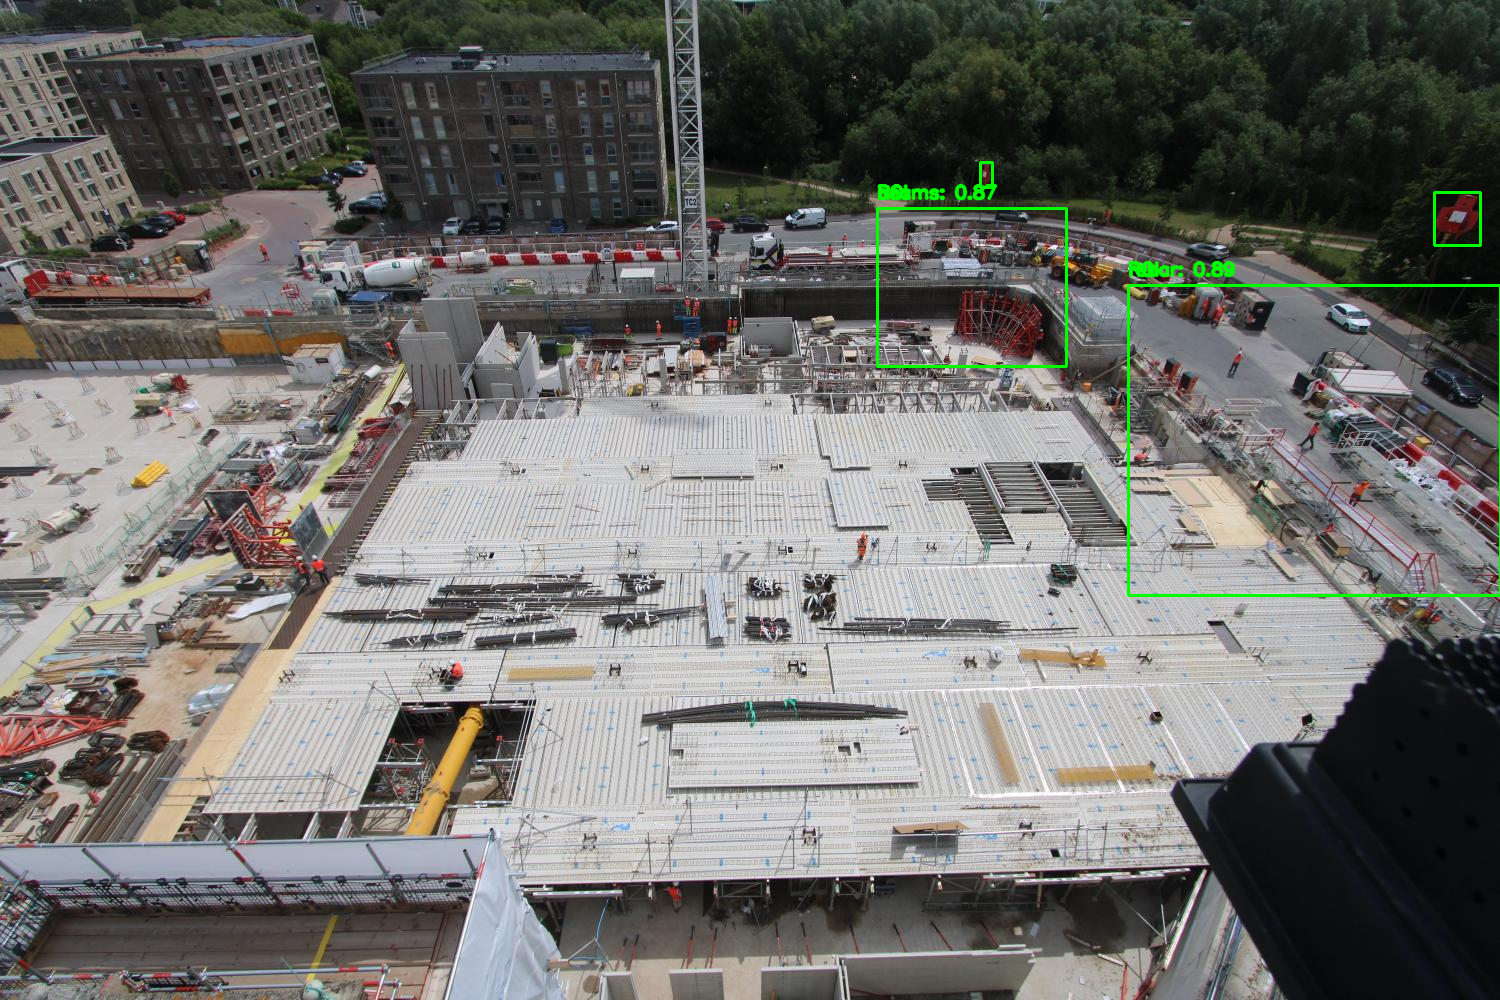

In [110]:
cv2_imshow(img)

# Know Your Load Exactly

## ROI Predict Class


In [ ]:
class LinearRegression(torch.nn.Module):
    def __init__(self, in_feat, out_feat, hidden):
        super().__init__()
        self.linear = torch.nn.Sequential(
            torch.nn.Linear(in_feat, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, out_feat),
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        return self.linear(x)

class Roi_Predict:
  def __init__(self, model_path):
    self.model = LinearRegression(5, 2, 64)
    state = torch.load(model_path,
                        map_location="cpu",
                        weights_only=True)
    self.model.load_state_dict(state)
    self.model.eval()

  def predict_load_roi(self, img_size, hook_coords):
    """
    hook_coords: normalized YOLO (x_center, y_center, w, h) in [0,1]
    img_size: (img_height, img_width) or (H, W, C) - we use first two.
    dims: optional crop size control
    returns: x top, y top, roi width, roi height
    """

    # image dims
    img_height = int(img_size[0])
    img_width  = int(img_size[1])

    hook_coords_np = np.asarray(hook_coords, dtype=np.float32).reshape(-1)

    x, y, w, h = hook_coords_np  # normalized
    yb_hook = y + (h / 2.0)

    # features for scaler: [x, y, w, h, yb_hook]
    hook_features = np.array([[x, y, w, h, yb_hook]], dtype=np.float32)
    xs_scaled = feat_scaler.transform(hook_features)  # numpy (1, 5)

    # Get predictions
    xs_t = torch.from_numpy(xs_scaled).float() #.to(device)
    self.model.eval()
    with torch.no_grad():
        pred_scaled = self.model(xs_t).cpu().numpy()

      # pred_inv is [dx, dy]
    pred_inv = target_scaler.inverse_transform(pred_scaled.reshape(1, -1))
    print(pred_inv)
    # dx, dy = pred_inv[0]
    dx, dy = float(pred_inv[0, 0]), float(pred_inv[0, 1])

    # ---- apply offsets relative to hook size (still normalized [0-1]) ----
    x_pred = x + (dx * w)
    y_pred = yb_hook + (dy * h)

    xc = int(round(x_pred * img_width ))
    yc = int(round(y_pred * img_height))

    #crop to top of hook
    gap_pixels = yc - (yb_hook * img_height)

    crop_h = int(gap_pixels * 1.6)
    crop_w = int(crop_h * 1.2)      # Usually loads are wider than they are tall

    xt = int(xc - (crop_w // 2))
    yt = int(yc - (crop_h // 2))

    # Clamp to image bounds
    xt = max(0, min(xt, img_width - crop_w))
    yt = max(0, min(yt, img_height - crop_h))

    return xt, yt, crop_w, crop_h

## Load Classifier Class

In [ ]:
import torch
import albumentations as A
import numpy as np

class Load_Classify:
    def __init__(self, path_to_model):
        self.path = path_to_model
        checkpoint = torch.load(
            self.path,
            map_location='cpu',
            weights_only=False
        )

        self.class_model = checkpoint["model"]
        self.class_model.eval()

        if torch.cuda.is_available():
            self.class_model.cuda()

        self.cls_names = checkpoint["cls_names"]
        self.cls_index = checkpoint["cls_index"]
        self.val_transforms = A.Compose([
            A.Resize(height=240, width=240),
            A.Normalize(mean=(0.485, 0.456, 0.406),
                        std=(0.229, 0.224, 0.225),
                        max_pixel_value=255.0),
        ])

    def predict_one_image(self, image_array):
        model = self.class_model
        transforms = self.val_transforms

        # model.eval()
        transformed = transforms(image=image_array)['image']
        x = np.transpose(transformed, (2, 0, 1))
        x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)

        if torch.cuda.is_available():
            x = x.cuda()

        with torch.no_grad():
            output = model(x)
            probs = torch.softmax(output, dim=1)
            pred_idx = probs.argmax(dim=1).item()
            confidence = probs[0, pred_idx].item()

        pred_class = self.cls_names[pred_idx]
        return pred_class, confidence

## KYLE Class

In [ ]:
from pydantic import BaseModel

class Box_Result(BaseModel):
    class_type: str
    conf: float
    x_top: int
    y_top: int
    width: int
    height: int

class Image_Result(BaseModel):
    image_name: str
    image_size: tuple
    image_results: list[Box_Result]

In [ ]:
from ultralytics import YOLO
import cv2
import torch
import numpy as np
from pathlib import Path

def cv_show(name, image):
    cv2.imshow(name, image)
    cv2.waitKey(5000)
    cv2.destroyAllWindows()

class KYLE:
    def __init__(self, objd_model, roi_model, classify_model):
        self.objd_model = objd_model
        self.roi_predict = roi_model
        self.classify_model = classify_model
        self.predictions = []

    def _crop_load(self, img, x, y, w, h):
        return img[y:y+h, x:x+w]

    def _second_stage_detector(self, crop, roi_size):
      """
        From ROI crop predict new object using YOLO
        If object found returns cropped image, local x1 x2, local y1 y2, confidence
        Else - None, 0,0,0,0,0

      """
      print("Predicting Second Crop")
      ss_results = self.objd_model.predict(crop, imgsz=roi_size, stream=False)

      for result in ss_results:
        if not result.boxes:
          continue

        for box in result.boxes.cpu():
            class_id = int(box.cls[0])
            class_name = self.objd_model.names[class_id]  # Get class name using the class ID
            conf = float(box.conf[0])
            label = f"{class_name}: {conf:.2f}"

            if class_id == 1: #Load Class
            #  LOCAL coordinates (relative to the ROI) top left, bottom right
              lx1, ly1, lx2, ly2 = box.xyxy[0].cpu().numpy().astype(int)

              # actual cropped image of the load
              load_only_crop = crop[ly1:ly2, lx1:lx2]
              return load_only_crop, lx1, ly1, lx2, ly2, conf
      return None, 0,0,0,0, 0

    def _predict_from_hook(self, image, box_size, hook_dims):
      """ Input original image, predict the ROI from first pass
          Pass through second stage object detector.
          Classify results
          returns x left, y top, w, h
       """
      print("predict from hook box size and dims",box_size, hook_dims)
      roi = self.roi_predict.predict_load_roi(box_size, hook_dims)
      xl, yt, crop_w, crop_h = roi

      # extract the ROI from the main image
      ROI = image[yt:yt+crop_h, xl:xl+crop_w]
      if ROI.size == 0: return

      # Find the load inside that ROI
      load_crop, lx1, ly1, lx2, ly2, yolo_conf = self._second_stage_detector(ROI, max(crop_w, crop_h))

      if load_crop is not None:
          print("Second ROI detected")
          # GLOBAL COORDINATES: ROI start + Local YOLO start
          gx1, gy1 = xl + lx1, yt + ly1
          gx2, gy2 = xt + lx2, yt + ly2

          w, h = gx2 - gx1, gy2 - gy1

          # Draw the final accurate box
          # predicted_class, confidence = self.classify_model.predict_one_image(load_crop)
          # xl, yt, w, h
          return gx1,gy1,w,h
          # return gx1, gy1
      else:
          print("MLP proposed a region, but YOLO stage 2 found no load there.")
          # xl, yt, w, h
          return roi

    # YOLO detection
    def _detect(self, results, image):

      if results is None:
        raise ValueError("detect() received image=None")
      # image MUST be a decoded numpy array
      if image is None:
        raise ValueError("detect() received image=None")

      if not isinstance(image, np.ndarray):
        raise TypeError(f"detect() expected numpy array, got {type(image)}")

      _img = image.copy()  # safe copy

      for idx, result in enumerate(results):
        #   if (type(image) is list): #is array(list) - issue may result if the stream isnt a list
        #     img = cv2.imread(image[idx])
        image_results = []
        print(result.boxes)
        if not result.boxes:
          print("No results")
          continue

        for box in result.boxes.cpu():
          r = box.xyxy[0].numpy().astype(int) # Get corner points as int (Actual Co-ords)
          class_id = int(box.cls[0])  # Get class ID
          class_name = self.objd_model.names[class_id]  # Get class name using the class ID
          conf = float(box.conf[0])
          print(f"Class: {class_name}, Box: {r}")  # Print class name and box coordinates
          label = f"{class_name}: {conf:.2f}"
          # -----------------------------------
          # LOAD (class 1)
          # -----------------------------------
          if class_id == 1:
              xt, yt, xb, yb = r
              w, h = box.xywh.numpy()[0].astype(int)[2:4]

              crop = self._crop_load(img, xt, yt, w, h)
              pred_class, confidence = self.classify_model.predict_one_image(crop)

              crop_result = Box_Result(class_type=pred_class, conf=conf, x_top=xt, y_top=yt, width=w, height=h)
              image_results.append(crop_result)

          # -----------------------------------
          # HOOK (class 0)
          # -----------------------------------
          else:
            hook_dims = box.xywhn[0]
            print("Hook found - Crop ROI")

            roi_dims = self._predict_from_hook(_img, box.orig_shape, hook_dims)
            if roi_dims is None:
              print("ROI is empty")
              continue

            roi_crop = self._crop_load(_img, *roi_dims)
            pred_class, confidence = self.classify_model.predict_one_image(roi_crop) #Return final preditions

            crop_result = Box_Result(
                class_type=pred_class,
                conf=conf, x_top=roi_dims[0],
                y_top=roi_dims[1],
                width=roi_dims[2],
                height=roi_dims[3])

            image_results.append(crop_result)

        load_results = Image_Result(image_name= result.path,image_results = image_results, image_size=result.orig_shape)
      return load_results

    #Run inference on one image
    def detect_image(self, image):
        obj_detect_results = self.objd_model.predict(image, stream=False)
        if obj_detect_results is None:
          print("No predictions")
          return
        crop_results = self._detect(obj_detect_results, image)
        self.predictions.append(crop_results)
        return crop_results

    #Run inference on bulk images - upload array of images.
    def detect_stream(self, stream):
        results = self.objd_model.predict(stream, stream=True)
        self._detect(results, stream)

## Run KYLE Model

In [ ]:
best_weights = "/content/drive/MyDrive/Crane-Detector/runs/detect/best_260126_train7/weights/best.pt"
yolo_model = yolo_model = YOLO(best_weights)

ROI_PATH = "/content/drive/MyDrive/Crane-Detector/LoadRegressionModel/LoadRegressionStandardv2.pth"
roi_predict = Roi_Predict(ROI_PATH)

CLS_PATH = "/content/drive/MyDrive/Crane-Detector/Image_Classes/crane_classifier.pth"
class_model = Load_Classify(CLS_PATH)

In [ ]:
# class KYLE:
#     def __init__(self, objd_model, weight_path, roi_model, classify_model):
yolo = YOLO(best_weights)

kyle = KYLE(yolo_model, roi_predict, class_model);

In [ ]:
img = cv2.imread('/content/drive/MyDrive/Crane-Detector/First Experiment/All_2LCS_AUG/test/images/2505301040060000_jpg.rf.e1ed3ff61e40b48bd7aecdf5f7df6050.jpg') #1 hook, 1 load

In [ ]:
kyle.detect_image(img)


0: 1376x2048 1 crane_hook, 1 crane_load, 1574.0ms
Speed: 72.2ms preprocess, 1574.0ms inference, 4.6ms postprocess per image at shape (1, 3, 1376, 2048)
ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0., 1.])
conf: tensor([0.8184, 0.6396])
data: tensor([[5.9809e+02, 2.2238e+02, 6.2341e+02, 2.6180e+02, 8.1841e-01, 0.0000e+00],
        [1.3278e+03, 1.2444e+02, 1.4108e+03, 2.0726e+02, 6.3960e-01, 1.0000e+00]])
id: None
is_track: False
orig_shape: (1000, 1500)
shape: torch.Size([2, 6])
xywh: tensor([[ 610.7498,  242.0908,   25.3257,   39.4160],
        [1369.2727,  165.8505,   83.0112,   82.8222]])
xywhn: tensor([[0.4072, 0.2421, 0.0169, 0.0394],
        [0.9128, 0.1659, 0.0553, 0.0828]])
xyxy: tensor([[ 598.0869,  222.3828,  623.4126,  261.7988],
        [1327.7671,  124.4393, 1410.7783,  207.2616]])
xyxyn: tensor([[0.3987, 0.2224, 0.4156, 0.2618],
        [0.8852, 0.1244, 0.9405, 0.2073]])
Class: crane_hook, Box: [598 222 623 261]
Hook found - Crop ROI
predict fro

Image_Result(image_name='image0.jpg', image_size=(1000, 1500), image_results=[Box_Result(class_type='beams', conf=0.8184087872505188, x_top=482, y_top=301, width=368, height=307), Box_Result(class_type='formwork', conf=0.6395987868309021, x_top=1327, y_top=124, width=83, height=82)])

In [ ]:
kyle.predictions

[Image_Result(image_name='image0.jpg', image_size=(1000, 1500), image_results=[Box_Result(class_type='beams', conf=0.8184087872505188, x_top=482, y_top=301, width=368, height=307), Box_Result(class_type='formwork', conf=0.6395987868309021, x_top=1327, y_top=124, width=83, height=82)])]

In [ ]:
# import numpy as np
# import torch

#   def predict_one_image(self, image_array, transforms=val_transforms):
#     """
#     Predict class for a single image from test set
#     """
#     self.load_cls_model.eval()

#     # Apply transforms
#     transformed = transforms(image=image_array)['image']
#     x = np.transpose(transformed, (2, 0, 1))
#     x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)  # Add batch dimension

#     # Move to GPU if available
#     if torch.cuda.is_available():
#         x = x.cuda()

#     with torch.no_grad():
#         output = self.load_cls_model(x)
#         probs = torch.softmax(output, dim=1)
#         pred_idx = probs.argmax(dim=1).item()
#         confidence = probs[0, pred_idx].item()

#     pred_class = cls_names[pred_idx]

#     return pred_class, confidence

#   def detect():
#     for result in results:
#     boxes = result.boxes.cpu()  # Get boxes on CPU in numpy format
#     print(len(boxes))
#     for box in boxes:  # Iterate over boxes
#         r = box.xyxy[0].numpy().astype(int) # Get corner points as int (Actual Co-ords)
#         class_id = int(box.cls[0])  # Get class ID
#         class_name = yolo_model.names[class_id]  # Get class name using the class ID
#         conf = float(box.conf[0])
#         print(f"Class: {class_name}, Box: {r}")  # Print class name and box coordinates
#         label = f"{class_name}: {conf:.2f}"

#         # Get predicted co-ordinates if not load detected

#         if class_id == 0: #Hook Class
#           dims = box.xywhn[0]
#           print("Hook found - Crop ROI")
#           predict_from_hook(img, box.orig_shape, dims, class_model)

#         if class_id == 1: #Load Class
#           xt, yt, xb, yb = r
#           w, h = box.xywh.numpy()[0].astype(int)[2:4]
#           crop = crop_load(img, xt,yt,w,h)
#           cv2_imshow(crop)

#           #classify
#           predicted_class, confidence = predict_one_image(class_model, crop)
#           print(f"Predicted Original Class: {predicted_class}")
#           print(f"Confidence of Original: {confidence:.4f} ({confidence*100:.2f}%)")

#           cv2.rectangle(img, r[:2], r[2:], (0, 255, 0), 2)
#           cv2.putText(img, f"{predicted_class}: {confidence:.2f}", (xt, yt - 10),
#             cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2, cv2.LINE_AA)



In [ ]:
cv2_imshow(img)

## Further Improvement - Notes
  - Model currently off on prediction of locations:
    - Potentially crop several regions, classify each region then NMS on probability
    - More regression training (More data / augmentations? / more features (Height of hook etc).
  - Classification isn't great, 60% in training and doesnt performs too great in this model.
    Suggestions:
      - increase number of training data (More manual crops from lobster cam) and better quality images.
      - Include a not class (Background / Not a load)
      - Play around with transforms and augmentations
      - Increase model architecture.
      - TTA
  - Finish the Muli-Res YOLO model.